# Packages + Data Load

In [100]:
import kagglehub
from dotenv import load_dotenv
import os

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
from dotenv import load_dotenv
import os

# 1. Load variables from .env into the environment
load_dotenv() 

# 2. Access them using the standard OS library
kaggle_user = os.getenv('KAGGLE_USERNAME')
kaggle_key = os.getenv('KAGGLE_KEY')

# Download the latest version of the competition data
path = kagglehub.competition_download("house-prices-advanced-regression-techniques")

print("Path to competition files:", path)

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv(os.path.join(path, "train.csv"))
df_test = pd.read_csv(os.path.join(path, "test.csv"))

Path to competition files: C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\data_description.txt
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\sample_submission.csv
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\test.csv
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\train.csv


# Overall look

In [102]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.info()
df.head()

Number of rows: 1460
Number of columns: 81
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Null Handling

In [103]:
series = df.isna().sum().sort_values(ascending=False)
print(len(series[series > 0]))
series[series > 0]


19


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Didn't know this but a lot of these Nulls aren't actually Nulls, but pandas readcsv actually reads certain values ("NA", "None") as nulls. Rather than updating the read statement just going to handle them explicilty.

In [ ]:
# Columns where NA is intentional to mean "Absent"
na_means_absent_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
                         'GarageQual', 'GarageFinish', 'GarageType', 'GarageCond', 'BsmtFinType2', 'BsmtExposure', 
                         'BsmtCond', 'BsmtQual', 'BsmtFinType1']

# Columns where NA is likely missing data that should be  inferrable
# GarageYrBlt - likely can be inferred from GarageType or GarageFinish
# LotFrontage - NOT clear where it can be inferred, but null may just mean no frontage
# MasVnrArea - likely can be inferred from MasVnrType
# Electrical
na_means_missing_cols_but_inferrable = ['GarageYrBlt','LotFrontage', 'MasVnrArea']

# Columns where NA is likely missing data and needs imputation
na_means_missing_cols = ['Electrical']

print("NA Columns where NA means Absent:", len(na_means_absent_cols))
print("NA Columns where NA means Missing but Inferrable:", len(na_means_missing_cols_but_inferrable))
print("NA Columns where NA means Missing:", len(na_means_missing_cols))

len(series[series > 0]) == len(na_means_absent_cols) + len(na_means_missing_cols_but_inferrable) + len(na_means_missing_cols)

NA Columns where NA means Absent: 15
NA Columns where NA means Missing but Inferrable: 3
NA Columns where NA means Missing: 1


True

In [ ]:
df['GarageYrBlt', df[['GarageYrBlt', 'GarageType', 'GarageFinish']].isna()]

InvalidIndexError: ('GarageYrBlt',       GarageYrBlt  GarageType  GarageFinish
0           False       False         False
1           False       False         False
2           False       False         False
3           False       False         False
4           False       False         False
...           ...         ...           ...
1455        False       False         False
1456        False       False         False
1457        False       False         False
1458        False       False         False
1459        False       False         False

[1460 rows x 3 columns])

In [ ]:
# Check that NA missings for inferrables are in fact inferrable
for col in na_means_missing_cols_but_inferrable:
    print(f"Column: {col}")
    if col == 'GarageYrBlt':
        df['GarageYrBlt', df[['GarageYrBlt', 'GarageType', 'GarageFinish'].isna()]]




Column: GarageYrBlt
        Id MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
39      40         90       RL         65.0     6040   Pave  None      Reg   
48      49        190       RM         33.0     4456   Pave  None      Reg   
78      79         90       RL         72.0    10778   Pave  None      Reg   
88      89         50  C (all)        105.0     8470   Pave  None      IR1   
89      90         20       RL         60.0     8070   Pave  None      Reg   
...    ...        ...      ...          ...      ...    ...   ...      ...   
1349  1350         70       RM         50.0     5250   Pave  Pave      Reg   
1407  1408         20       RL          NaN     8780   Pave  None      IR1   
1449  1450        180       RM         21.0     1533   Pave  None      Reg   
1450  1451         90       RL         60.0     9000   Pave  None      Reg   
1453  1454         20       RL         90.0    17217   Pave  None      Reg   

     LandContour Utilities  ... MiscVal MoS

In [ ]:
# Fill NA values for columns where NA means Absent with "None"
for col in na_means_absent_cols:
    df[col] = df[col].fillna("None")
    df_test[col] = df_test[col].fillna("None")

# Cat and Num cols

In [6]:
print("Totals columns:", df.shape[1])
print("\n")
cat_cols = df.select_dtypes(include="str").columns
num_cols = df.select_dtypes(include="number").columns  

cat_cols_sorted = sorted(cat_cols)
print("Categorical columns:", np.array(cat_cols_sorted))
print("Number of categorical columns:", len(cat_cols_sorted))

Totals columns: 81


Categorical columns: ['Alley' 'BldgType' 'BsmtCond' 'BsmtExposure' 'BsmtFinType1'
 'BsmtFinType2' 'BsmtQual' 'CentralAir' 'Condition1' 'Condition2'
 'Electrical' 'ExterCond' 'ExterQual' 'Exterior1st' 'Exterior2nd' 'Fence'
 'FireplaceQu' 'Foundation' 'Functional' 'GarageCond' 'GarageFinish'
 'GarageQual' 'GarageType' 'Heating' 'HeatingQC' 'HouseStyle'
 'KitchenQual' 'LandContour' 'LandSlope' 'LotConfig' 'LotShape' 'MSZoning'
 'MasVnrType' 'MiscFeature' 'Neighborhood' 'PavedDrive' 'PoolQC'
 'RoofMatl' 'RoofStyle' 'SaleCondition' 'SaleType' 'Street' 'Utilities']
Number of categorical columns: 43


In [7]:
num_cols_sorted = sorted(num_cols)
print("Numerical columns:", np.array(num_cols_sorted))
print("Number of numerical columns:", len(num_cols_sorted))

Numerical columns: ['1stFlrSF' '2ndFlrSF' '3SsnPorch' 'BedroomAbvGr' 'BsmtFinSF1'
 'BsmtFinSF2' 'BsmtFullBath' 'BsmtHalfBath' 'BsmtUnfSF' 'EnclosedPorch'
 'Fireplaces' 'FullBath' 'GarageArea' 'GarageCars' 'GarageYrBlt'
 'GrLivArea' 'HalfBath' 'Id' 'KitchenAbvGr' 'LotArea' 'LotFrontage'
 'LowQualFinSF' 'MSSubClass' 'MasVnrArea' 'MiscVal' 'MoSold' 'OpenPorchSF'
 'OverallCond' 'OverallQual' 'PoolArea' 'SalePrice' 'ScreenPorch'
 'TotRmsAbvGrd' 'TotalBsmtSF' 'WoodDeckSF' 'YearBuilt' 'YearRemodAdd'
 'YrSold']
Number of numerical columns: 38


# Transformations

In [8]:
# Misclassifications
df['Id'] = df['Id'].astype(str)
df['MSSubClass'] = df['MSSubClass'].astype(str)

# Feature Engineering

In [9]:
df['YearBuilt_AGE'] = df['YrSold'] - df['YearBuilt']
df['YearReMod_AGE'] = df['YrSold'] - df['YearRemodAdd']
df['GarageYrBlt_AGE'] = df['YrSold'] - df['GarageYrBlt']

df['WasReModded'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# Categorical

## Alley

In [10]:
"""Alley: Type of alley access to property

       Grvl	Gravel
       Pave	Paved
       NA 	No alley access"""
df['Alley'].value_counts(dropna=False)

Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

## BldgType

In [11]:
"""BldgType: Type of dwelling

       1Fam	Single-family Detached
       2FmCon	Two-family Conversion; originally built as one-family dwelling
       Duplx	Duplex
       TwnhsE	Townhouse End Unit
       TwnhsI	Townhouse Inside Unit"""
df['BldgType'].value_counts(dropna=False)

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

## BsmtCond

In [12]:
"""BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement"""
df['BsmtCond'].value_counts(dropna=False)

BsmtCond
TA     1311
Gd       65
Fa       45
NaN      37
Po        2
Name: count, dtype: int64

## BsmtExposure

In [13]:
"""BsmtExposure: Refers to walkout or garden level walls

       Gd	Good Exposure
       Av	Average Exposure (split levels or foyers typically score average or above)
       Mn	Minimum Exposure
       No	No Exposure
       NA	No Basement"""
df['BsmtExposure'].value_counts(dropna=False)

BsmtExposure
No     953
Av     221
Gd     134
Mn     114
NaN     38
Name: count, dtype: int64

## BsmtFinType1

In [14]:
"""BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinished
       NA	No Basement"""
df['BsmtFinType1'].value_counts(dropna=False)

BsmtFinType1
Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
NaN     37
Name: count, dtype: int64

## BsmtFinType2

In [15]:
"""BsmtFinType2: Rating of basement finished area (if multiple types)

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinished
       NA	No Basement"""
df['BsmtFinType2'].value_counts(dropna=False)

BsmtFinType2
Unf    1256
Rec      54
LwQ      46
NaN      38
BLQ      33
ALQ      19
GLQ      14
Name: count, dtype: int64

## BsmtQual

In [16]:
"""BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches)
       NA	No Basement"""
df['BsmtQual'].value_counts(dropna=False)

BsmtQual
TA     649
Gd     618
Ex     121
NaN     37
Fa      35
Name: count, dtype: int64

## CentralAir

In [17]:
"""CentralAir: Central air conditioning

       N	No
       Y	Yes"""
df['CentralAir'].value_counts(dropna=False)

CentralAir
Y    1365
N      95
Name: count, dtype: int64

## Condition1

In [18]:
"""Condition1: Proximity to various conditions

       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street
       Norm	Normal
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to positive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad"""
df['Condition1'].value_counts(dropna=False)

Condition1
Norm      1260
Feedr       81
Artery      48
RRAn        26
PosN        19
RRAe        11
PosA         8
RRNn         5
RRNe         2
Name: count, dtype: int64

## Condition2

In [19]:
"""Condition2: Proximity to various conditions (if more than one is present)

       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street
       Norm	Normal
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to positive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad"""
df['Condition2'].value_counts(dropna=False)

Condition2
Norm      1445
Feedr        6
Artery       2
RRNn         2
PosN         2
PosA         1
RRAn         1
RRAe         1
Name: count, dtype: int64

## Electrical

In [20]:
"""Electrical: Electrical system

       SBrkr	Standard Circuit Breakers & Romex
       FuseA	Fuse Box over 60 AMP and all Romex wiring (Average)
       FuseF	60 AMP Fuse Box and mostly Romex wiring (Fair)
       FuseP	60 AMP Fuse Box and mostly knob & tube wiring (poor)
       Mix	Mixed"""
df['Electrical'].value_counts(dropna=False)

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64

## ExterCond

In [21]:
"""ExterCond: Evaluates the present condition of the material on the exterior

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor"""
df['ExterCond'].value_counts(dropna=False)

ExterCond
TA    1282
Gd     146
Fa      28
Ex       3
Po       1
Name: count, dtype: int64

## ExterQual

In [22]:
"""ExterQual: Evaluates the quality of the material on the exterior

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor"""
df['ExterQual'].value_counts(dropna=False)

ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64

## Exterior1st

In [23]:
"""Exterior1st: Exterior covering on house

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	       Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	       Other
       Plywood	Plywood
       PreCast	PreCast
       Stone	       Stone
       Stucco	       Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles"""
df['Exterior1st'].value_counts(dropna=False)

Exterior1st
VinylSd    515
HdBoard    222
MetalSd    220
Wd Sdng    206
Plywood    108
CemntBd     61
BrkFace     50
WdShing     26
Stucco      25
AsbShng     20
BrkComm      2
Stone        2
AsphShn      1
ImStucc      1
CBlock       1
Name: count, dtype: int64

## Exterior2nd

In [24]:
"""Exterior2nd: Exterior covering on house (if more than one material)

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles"""
df['Exterior2nd'].value_counts(dropna=False)

Exterior2nd
VinylSd    504
MetalSd    214
HdBoard    207
Wd Sdng    197
Plywood    142
CmentBd     60
Wd Shng     38
Stucco      26
BrkFace     25
AsbShng     20
ImStucc     10
Brk Cmn      7
Stone        5
AsphShn      3
Other        1
CBlock       1
Name: count, dtype: int64

## Fence

In [25]:
"""Fence: Fence quality

       GdPrv	Good Privacy
       MnPrv	Minimum Privacy
       GdWo	Good Wood
       MnWw	Minimum Wood/Wire
       NA	No Fence"""
df['Fence'].value_counts(dropna=False)

Fence
NaN      1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64

## FireplaceQu

In [26]:
"""FireplaceQu: Fireplace quality

       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace"""
df['FireplaceQu'].value_counts(dropna=False)

FireplaceQu
NaN    690
Gd     380
TA     313
Fa      33
Ex      24
Po      20
Name: count, dtype: int64

## Foundation

In [27]:
"""Foundation: Type of foundation

       BrkTil	Brick & Tile
       CBlock	Cinder Block
       PConc	Poured Concrete
       Slab	Slab
       Stone	Stone
       Wood	Wood"""
df['Foundation'].value_counts(dropna=False)

Foundation
PConc     647
CBlock    634
BrkTil    146
Slab       24
Stone       6
Wood        3
Name: count, dtype: int64

## Functional

In [28]:
"""Functional: Home functionality (Assume typical unless deductions are warranted)

       Typ	Typical Functionality
       Min1	Minor Deductions 1
       Min2	Minor Deductions 2
       Mod	Moderate Deductions
       Maj1	Major Deductions 1
       Maj2	Major Deductions 2
       Sev	Severely Damaged
       Sal	Salvage only"""
df['Functional'].value_counts(dropna=False)

Functional
Typ     1360
Min2      34
Min1      31
Mod       15
Maj1      14
Maj2       5
Sev        1
Name: count, dtype: int64

## GarageCond

In [29]:
"""GarageCond: Garage condition

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage"""
df['GarageCond'].value_counts(dropna=False)

GarageCond
TA     1326
NaN      81
Fa       35
Gd        9
Po        7
Ex        2
Name: count, dtype: int64

## GarageFinish

In [30]:
"""GarageFinish: Interior finish of the garage

       Fin	Finished
       RFn	Rough Finished
       Unf	Unfinished
       NA	No Garage"""
df['GarageFinish'].value_counts(dropna=False)

GarageFinish
Unf    605
RFn    422
Fin    352
NaN     81
Name: count, dtype: int64

## GarageQual

In [31]:
"""GarageQual: Garage quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage"""
df['GarageQual'].value_counts(dropna=False)

GarageQual
TA     1311
NaN      81
Fa       48
Gd       14
Ex        3
Po        3
Name: count, dtype: int64

## GarageType

In [32]:
"""GarageType: Garage location

       2Types	More than one type of garage
       Attchd	Attached to home
       Basment	Basement Garage
       BuiltIn	Built-In (Garage part of house - typically has room above garage)
       CarPort	Car Port
       Detchd	Detached from home
       NA	No Garage"""
df['GarageType'].value_counts(dropna=False)

GarageType
Attchd     870
Detchd     387
BuiltIn     88
NaN         81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

## Heating

In [33]:
"""Heating: Type of heating

       Floor	Floor Furnace
       GasA	Gas forced warm air furnace
       GasW	Gas hot water or steam heat
       Grav	Gravity furnace
       OthW	Hot water or steam heat other than gas
       Wall	Wall furnace"""
df['Heating'].value_counts(dropna=False)

Heating
GasA     1428
GasW       18
Grav        7
Wall        4
OthW        2
Floor       1
Name: count, dtype: int64

## HeatingQC

In [34]:
"""HeatingQC: Heating quality and condition

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor"""
df['HeatingQC'].value_counts(dropna=False)

HeatingQC
Ex    741
TA    428
Gd    241
Fa     49
Po      1
Name: count, dtype: int64

## HouseStyle

In [35]:
"""HouseStyle: Style of dwelling

       1Story	One story
       1.5Fin	One and one-half story: 2nd level finished
       1.5Unf	One and one-half story: 2nd level unfinished
       2Story	Two story
       2.5Fin	Two and one-half story: 2nd level finished
       2.5Unf	Two and one-half story: 2nd level unfinished
       SFoyer	Split Foyer
       SLvl	Split Level"""
df['HouseStyle'].value_counts(dropna=False)

HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

## Id -- Meta Data

In [36]:
"""Id: Row identifier"""
df['Id'].describe()

count     1460
unique    1460
top          1
freq         1
Name: Id, dtype: object

## KitchenQual

In [37]:
"""KitchenQual: Kitchen quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor"""
df['KitchenQual'].value_counts(dropna=False)

KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

## LandContour

In [38]:
"""LandContour: Flatness of the property

       Lvl	Near Flat/Level
       Bnk	Banked - Quick and significant rise from street grade to building
       HLS	Hillside - Significant slope from side to side
       Low	Depression"""
df['LandContour'].value_counts(dropna=False)

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

## LandSlope

In [39]:
"""LandSlope: Slope of property

       Gtl	Gentle slope
       Mod	Moderate Slope
       Sev	Severe Slope"""
df['LandSlope'].value_counts(dropna=False)

LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

## LotConfig

In [40]:
"""LotConfig: Lot configuration

       Inside	Inside lot
       Corner	Corner lot
       CulDSac	Cul-de-sac
       FR2	Frontage on 2 sides of property
       FR3	Frontage on 3 sides of property"""
df['LotConfig'].value_counts(dropna=False)

LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

## LotShape

In [41]:
"""LotShape: General shape of property

       Reg	Regular
       IR1	Slightly irregular
       IR2	Moderately Irregular
       IR3	Irregular"""
df['LotShape'].value_counts(dropna=False)

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

## MSZoning

In [42]:
"""MSZoning: Identifies the general zoning classification of the sale

       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park
       RM	Residential Medium Density"""
df['MSZoning'].value_counts(dropna=False)

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

## MasVnrType

In [43]:
"""MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	None
       Stone	Stone"""
df['MasVnrType'].value_counts(dropna=False)

MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

## MiscFeature

In [44]:
"""MiscFeature: Miscellaneous feature not covered in other categories

       Elev	Elevator
       Gar2	2nd Garage (if not described in garage section)
       Othr	Other
       Shed	Shed (over 100 SF)
       TenC	Tennis Court
       NA	None"""
df['MiscFeature'].value_counts(dropna=False)

MiscFeature
NaN     1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64

## MSSubClass -- converted to cat

In [45]:
"""MSSubClass: Identifies the type of dwelling involved in the sale

       20	1-STORY 1946 & NEWER ALL STYLES
       30	1-STORY 1945 & OLDER
       40	1-STORY W/FINISHED ATTIC ALL AGES
       45	1-1/2 STORY - UNFINISHED ALL AGES
       50	1-1/2 STORY FINISHED ALL AGES
       60	2-STORY 1946 & NEWER
       70	2-STORY 1945 & OLDER
       75	2-1/2 STORY ALL AGES
       80	SPLIT OR MULTI-LEVEL
       85	SPLIT FOYER
       90	DUPLEX - ALL STYLES AND AGES
      120	1-STORY PUD - 1946 & NEWER
      150	1-1/2 STORY PUD - ALL AGES
      160	2-STORY PUD - 1946 & NEWER
      180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
      190	2 FAMILY CONVERSION - ALL STYLES AND AGES"""
df['MSSubClass'].value_counts().sort_index()

MSSubClass
120     87
160     63
180     10
190     30
20     536
30      69
40       4
45      12
50     144
60     299
70      60
75      16
80      58
85      20
90      52
Name: count, dtype: int64

## Neighborhood

In [46]:
"""Neighborhood: Physical locations within Ames city limits

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	Veenker"""
df['Neighborhood'].value_counts(dropna=False)

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

## PavedDrive

In [47]:
"""PavedDrive: Paved driveway

       Y	Paved
       P	Partial Pavement
       N	Dirt/Gravel"""
df['PavedDrive'].value_counts(dropna=False)

PavedDrive
Y    1340
N      90
P      30
Name: count, dtype: int64

## PoolQC

In [48]:
"""PoolQC: Pool quality

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       NA	No Pool"""
df['PoolQC'].value_counts(dropna=False)

PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

## RoofMatl

In [49]:
"""RoofMatl: Roof material

       ClyTile	Clay or Tile
       CompShg	Standard (Composite) Shingle
       Membran	Membrane
       Metal	Metal
       Roll	Roll
       Tar&Grv	Gravel & Tar
       WdShake	Wood Shakes
       WdShngl	Wood Shingles"""
df['RoofMatl'].value_counts(dropna=False)

RoofMatl
CompShg    1434
Tar&Grv      11
WdShngl       6
WdShake       5
Metal         1
Membran       1
Roll          1
ClyTile       1
Name: count, dtype: int64

## RoofStyle

In [50]:
"""RoofStyle: Type of roof

       Flat	Flat
       Gable	Gable
       Gambrel	Gabrel (Barn)
       Hip	Hip
       Mansard	Mansard
       Shed	Shed"""
df['RoofStyle'].value_counts(dropna=False)

RoofStyle
Gable      1141
Hip         286
Flat         13
Gambrel      11
Mansard       7
Shed          2
Name: count, dtype: int64

## SaleCondition

In [51]:
"""SaleCondition: Condition of sale

       Normal	Normal Sale
       Abnorml	Abnormal Sale - trade, foreclosure, short sale
       AdjLand	Adjoining Land Purchase
       Alloca	Allocation - two linked properties with separate deeds, typically condo with a garage unit
       Family	Sale between family members
       Partial	Home was not completed when last assessed (associated with New Homes)"""
df['SaleCondition'].value_counts(dropna=False)

SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64

## SaleType

In [52]:
"""SaleType: Type of sale

       WD	Warranty Deed - Conventional
       CWD	Warranty Deed - Cash
       VWD	Warranty Deed - VA Loan
       New	Home just constructed and sold
       COD	Court Officer Deed/Estate
       Con	Contract 15% Down payment regular terms
       ConLw	Contract Low Down payment and low interest
       ConLI	Contract Low Interest
       ConLD	Contract Low Down
       Oth	Other"""
df['SaleType'].value_counts(dropna=False)

SaleType
WD       1267
New       122
COD        43
ConLD       9
ConLI       5
ConLw       5
CWD         4
Oth         3
Con         2
Name: count, dtype: int64

## Street

In [53]:
"""Street: Type of road access to property

       Grvl	Gravel
       Pave	Paved"""
df['Street'].value_counts(dropna=False)

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

## Utilities

In [54]:
"""Utilities: Type of utilities available

       AllPub	All public Utilities (E,G,W,& S)
       NoSewr	Electricity, Gas, and Water (Septic Tank)
       NoSeWa	Electricity and Gas Only
       ELO	Electricity only"""
df['Utilities'].value_counts(dropna=False)

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

# Numerical

## 1stFlrSF

In [55]:
"""1stFlrSF: First floor square feet"""
df['1stFlrSF'].describe()

count    1460.000000
mean     1162.626712
std       386.587738
min       334.000000
25%       882.000000
50%      1087.000000
75%      1391.250000
max      4692.000000
Name: 1stFlrSF, dtype: float64

## 2ndFlrSF

In [56]:
"""2ndFlrSF: Second floor square feet"""
df['2ndFlrSF'].describe()

count    1460.000000
mean      346.992466
std       436.528436
min         0.000000
25%         0.000000
50%         0.000000
75%       728.000000
max      2065.000000
Name: 2ndFlrSF, dtype: float64

## 3SsnPorch

In [57]:
"""3SsnPorch: Three season porch area in square feet"""
df['3SsnPorch'].describe()

count    1460.000000
mean        3.409589
std        29.317331
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       508.000000
Name: 3SsnPorch, dtype: float64

## BedroomAbvGr

In [58]:
"""BedroomAbvGr: Bedrooms above grade (does NOT include basement bedrooms)"""
df['BedroomAbvGr'].describe()

count    1460.000000
mean        2.866438
std         0.815778
min         0.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         8.000000
Name: BedroomAbvGr, dtype: float64

## BsmtFinSF1

In [59]:
"""BsmtFinSF1: Type 1 finished square feet"""
df['BsmtFinSF1'].describe()

count    1460.000000
mean      443.639726
std       456.098091
min         0.000000
25%         0.000000
50%       383.500000
75%       712.250000
max      5644.000000
Name: BsmtFinSF1, dtype: float64

## BsmtFinSF2

In [60]:
"""BsmtFinSF2: Type 2 finished square feet"""
df['BsmtFinSF2'].describe()

count    1460.000000
mean       46.549315
std       161.319273
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      1474.000000
Name: BsmtFinSF2, dtype: float64

## BsmtFullBath

In [61]:
"""BsmtFullBath: Basement full bathrooms"""
df['BsmtFullBath'].describe()

count    1460.000000
mean        0.425342
std         0.518911
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         3.000000
Name: BsmtFullBath, dtype: float64

## BsmtHalfBath

In [62]:
"""BsmtHalfBath: Basement half bathrooms"""
df['BsmtHalfBath'].describe()

count    1460.000000
mean        0.057534
std         0.238753
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: BsmtHalfBath, dtype: float64

## BsmtUnfSF

In [63]:
"""BsmtUnfSF: Unfinished square feet of basement area"""
df['BsmtUnfSF'].describe()

count    1460.000000
mean      567.240411
std       441.866955
min         0.000000
25%       223.000000
50%       477.500000
75%       808.000000
max      2336.000000
Name: BsmtUnfSF, dtype: float64

## EnclosedPorch

In [64]:
"""EnclosedPorch: Enclosed porch area in square feet"""
df['EnclosedPorch'].describe()

count    1460.000000
mean       21.954110
std        61.119149
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       552.000000
Name: EnclosedPorch, dtype: float64

## Fireplaces

In [65]:
"""Fireplaces: Number of fireplaces"""
df['Fireplaces'].describe()

count    1460.000000
mean        0.613014
std         0.644666
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: Fireplaces, dtype: float64

## FullBath

In [66]:
"""FullBath: Full bathrooms above grade"""
df['FullBath'].describe()

count    1460.000000
mean        1.565068
std         0.550916
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: FullBath, dtype: float64

## GarageArea

In [67]:
"""GarageArea: Size of garage in square feet"""
df['GarageArea'].describe()

count    1460.000000
mean      472.980137
std       213.804841
min         0.000000
25%       334.500000
50%       480.000000
75%       576.000000
max      1418.000000
Name: GarageArea, dtype: float64

## GarageCars

In [68]:
"""GarageCars: Size of garage in car capacity"""
df['GarageCars'].describe()

count    1460.000000
mean        1.767123
std         0.747315
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         4.000000
Name: GarageCars, dtype: float64

## GarageYrBlt

In [69]:
"""GarageYrBlt: Year garage was built"""
df['GarageYrBlt'].describe()

count    1379.000000
mean     1978.506164
std        24.689725
min      1900.000000
25%      1961.000000
50%      1980.000000
75%      2002.000000
max      2010.000000
Name: GarageYrBlt, dtype: float64

## GrLivArea

In [70]:
"""GrLivArea: Above grade (ground) living area square feet"""
df['GrLivArea'].describe()

count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64

## HalfBath

In [71]:
"""HalfBath: Half baths above grade"""
df['HalfBath'].describe()

count    1460.000000
mean        0.382877
std         0.502885
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         2.000000
Name: HalfBath, dtype: float64

## KitchenAbvGr

In [72]:
"""KitchenAbvGr: Kitchens above grade"""
df['KitchenAbvGr'].describe()

count    1460.000000
mean        1.046575
std         0.220338
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: KitchenAbvGr, dtype: float64

## LotArea

In [73]:
"""LotArea: Lot size in square feet"""
df['LotArea'].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

## LotFrontage

In [74]:
"""LotFrontage: Linear feet of street connected to property"""
df['LotFrontage'].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

## LowQualFinSF

In [75]:
"""LowQualFinSF: Low quality finished square feet (all floors)"""
df['LowQualFinSF'].describe()

count    1460.000000
mean        5.844521
std        48.623081
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       572.000000
Name: LowQualFinSF, dtype: float64

## MasVnrArea

In [76]:
"""MasVnrArea: Masonry veneer area in square feet"""
df['MasVnrArea'].describe()

count    1452.000000
mean      103.685262
std       181.066207
min         0.000000
25%         0.000000
50%         0.000000
75%       166.000000
max      1600.000000
Name: MasVnrArea, dtype: float64

## MiscVal

In [77]:
"""MiscVal: Dollar value of miscellaneous feature"""
df['MiscVal'].describe()

count     1460.000000
mean        43.489041
std        496.123024
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      15500.000000
Name: MiscVal, dtype: float64

## MoSold

In [78]:
"""MoSold: Month sold (MM)"""
df['MoSold'].describe()

count    1460.000000
mean        6.321918
std         2.703626
min         1.000000
25%         5.000000
50%         6.000000
75%         8.000000
max        12.000000
Name: MoSold, dtype: float64

## OpenPorchSF

In [79]:
"""OpenPorchSF: Open porch area in square feet"""
df['OpenPorchSF'].describe()

count    1460.000000
mean       46.660274
std        66.256028
min         0.000000
25%         0.000000
50%        25.000000
75%        68.000000
max       547.000000
Name: OpenPorchSF, dtype: float64

## OverallCond -- labeled cat

In [80]:
"""OverallCond: Rates the overall condition of the house

       10	Very Excellent
        9	Excellent
        8	Very Good
        7	Good
        6	Above Average
        5	Average
        4	Below Average
        3	Fair
        2	Poor
        1	Very Poor"""
df['OverallCond'].value_counts().sort_index()

OverallCond
1      1
2      5
3     25
4     57
5    821
6    252
7    205
8     72
9     22
Name: count, dtype: int64

## OverallQual -- labeled cat

In [81]:
"""OverallQual: Rates the overall material and finish of the house

       10	Very Excellent
        9	Excellent
        8	Very Good
        7	Good
        6	Above Average
        5	Average
        4	Below Average
        3	Fair
        2	Poor
        1	Very Poor"""
df['OverallQual'].value_counts().sort_index()

OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64

## PoolArea

In [82]:
"""PoolArea: Pool area in square feet"""
df['PoolArea'].describe()

count    1460.000000
mean        2.758904
std        40.177307
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       738.000000
Name: PoolArea, dtype: float64

## SalePrice -- RESPONSE

In [83]:
"""SalePrice: Sale price in dollars (target variable)"""
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## ScreenPorch

In [84]:
"""ScreenPorch: Screen porch area in square feet"""
df['ScreenPorch'].describe()

count    1460.000000
mean       15.060959
std        55.757415
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       480.000000
Name: ScreenPorch, dtype: float64

## TotRmsAbvGrd

In [85]:
"""TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)"""
df['TotRmsAbvGrd'].describe()

count    1460.000000
mean        6.517808
std         1.625393
min         2.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        14.000000
Name: TotRmsAbvGrd, dtype: float64

## TotalBsmtSF

In [86]:
"""TotalBsmtSF: Total square feet of basement area"""
df['TotalBsmtSF'].describe()

count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
25%       795.750000
50%       991.500000
75%      1298.250000
max      6110.000000
Name: TotalBsmtSF, dtype: float64

## WoodDeckSF

In [87]:
"""WoodDeckSF: Wood deck area in square feet"""
df['WoodDeckSF'].describe()

count    1460.000000
mean       94.244521
std       125.338794
min         0.000000
25%         0.000000
50%         0.000000
75%       168.000000
max       857.000000
Name: WoodDeckSF, dtype: float64

## YearBuilt

In [88]:
"""YearBuilt: Original construction date"""
df['YearBuilt'].describe()

count    1460.000000
mean     1971.267808
std        30.202904
min      1872.000000
25%      1954.000000
50%      1973.000000
75%      2000.000000
max      2010.000000
Name: YearBuilt, dtype: float64

## YearRemodAdd

In [89]:
"""YearRemodAdd: Remodel date (same as construction date if no remodeling or additions)"""
df['YearRemodAdd'].describe()

count    1460.000000
mean     1984.865753
std        20.645407
min      1950.000000
25%      1967.000000
50%      1994.000000
75%      2004.000000
max      2010.000000
Name: YearRemodAdd, dtype: float64

## YrSold

In [90]:
"""YrSold: Year sold (YYYY)"""
df['YrSold'].describe()

count    1460.000000
mean     2007.815753
std         1.328095
min      2006.000000
25%      2007.000000
50%      2008.000000
75%      2009.000000
max      2010.000000
Name: YrSold, dtype: float64

# Graphing EDA

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 85 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               1460 non-null   str    
 1   MSSubClass       1460 non-null   str    
 2   MSZoning         1460 non-null   str    
 3   LotFrontage      1201 non-null   float64
 4   LotArea          1460 non-null   int64  
 5   Street           1460 non-null   str    
 6   Alley            91 non-null     str    
 7   LotShape         1460 non-null   str    
 8   LandContour      1460 non-null   str    
 9   Utilities        1460 non-null   str    
 10  LotConfig        1460 non-null   str    
 11  LandSlope        1460 non-null   str    
 12  Neighborhood     1460 non-null   str    
 13  Condition1       1460 non-null   str    
 14  Condition2       1460 non-null   str    
 15  BldgType         1460 non-null   str    
 16  HouseStyle       1460 non-null   str    
 17  OverallQual      1460 non

In [92]:
cat_cols=df.select_dtypes(include=['str']).columns
num_cols = df.select_dtypes(include=['int64', 'float']).columns
print("Categorical Variables:")
print(cat_cols)
print("\n")
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['Id', 'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir',
       'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='str')


Numerical Variables:
Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'Ful

## Graphing Categoricals

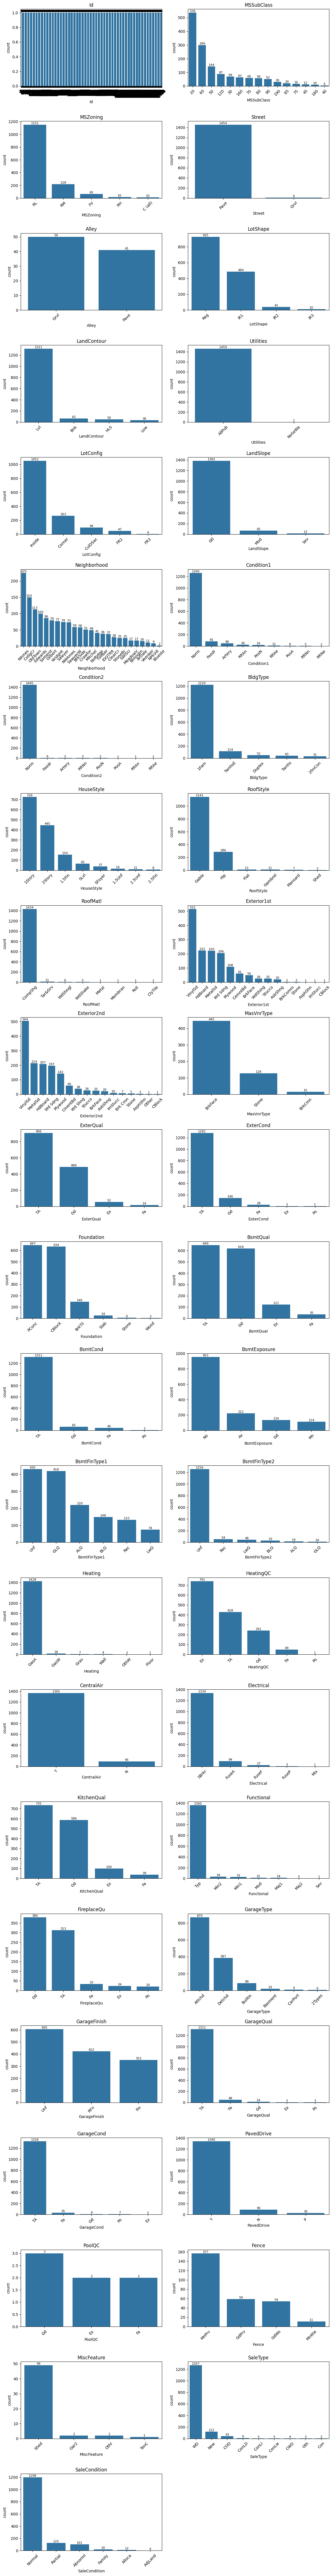

In [93]:
plots_per_row = 2

rows = math.ceil(len(cat_cols) / plots_per_row)

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, plots_per_row, i)
    sns.countplot(data=df, x=col,
                  order=df[col].value_counts().index)
    # Add value labels
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt='%d', padding=0, fontsize=8)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

## Graphing Numericals

LotFrontage
Skew : 2.16


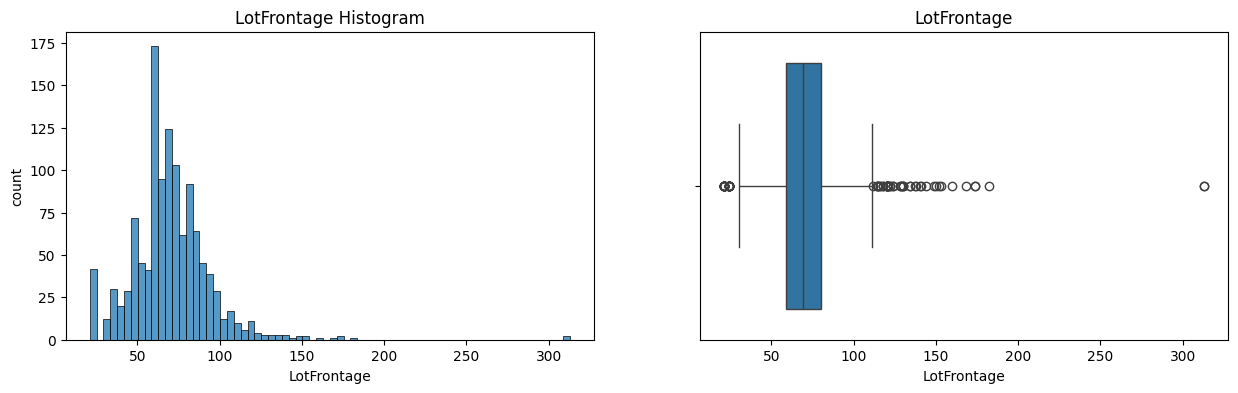

LotArea
Skew : 12.21


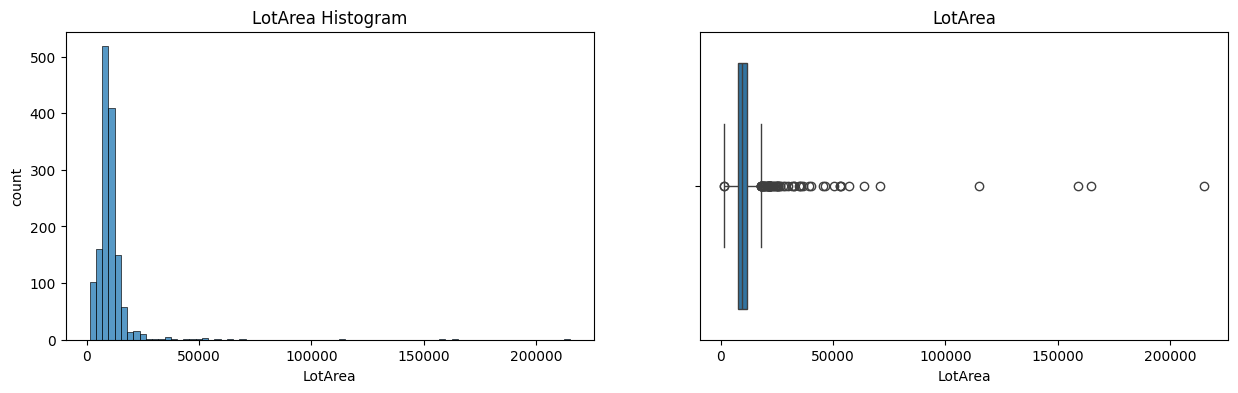

OverallQual
Skew : 0.22


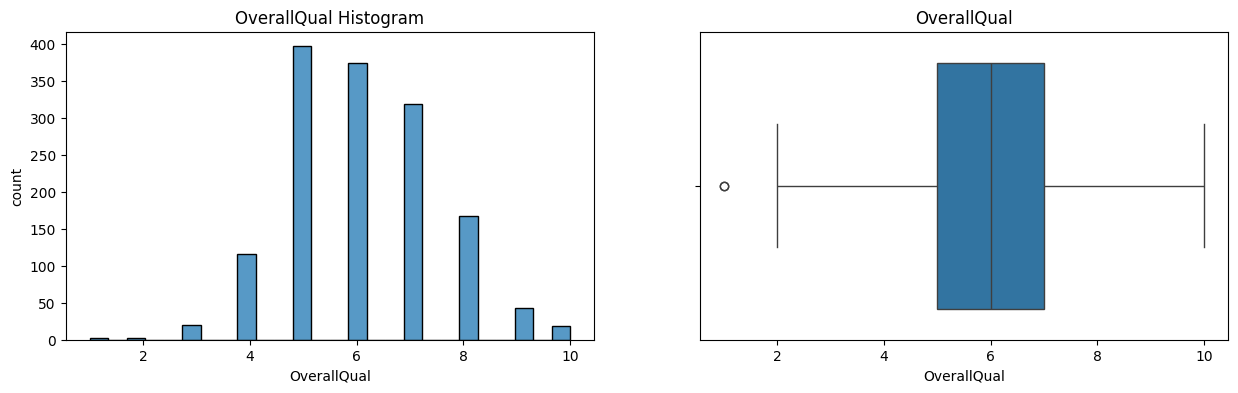

OverallCond
Skew : 0.69


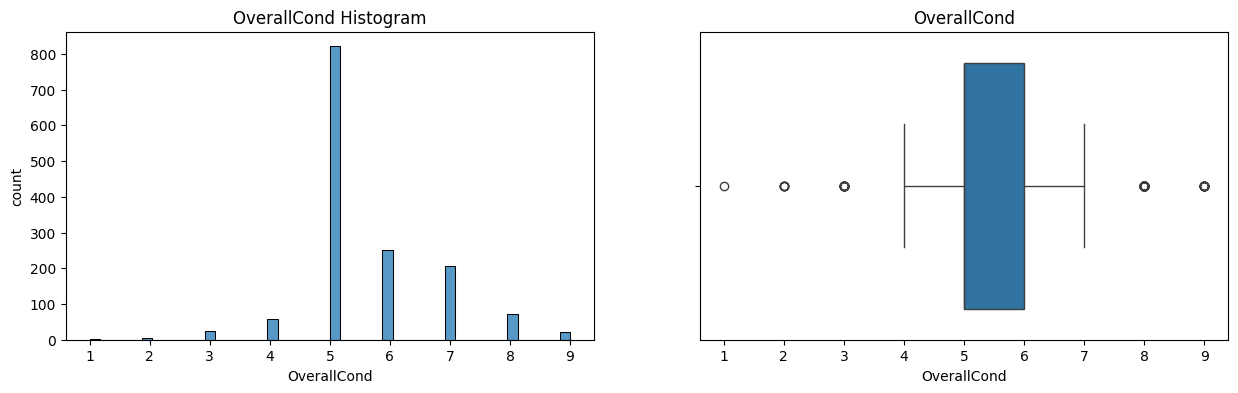

YearBuilt
Skew : -0.61


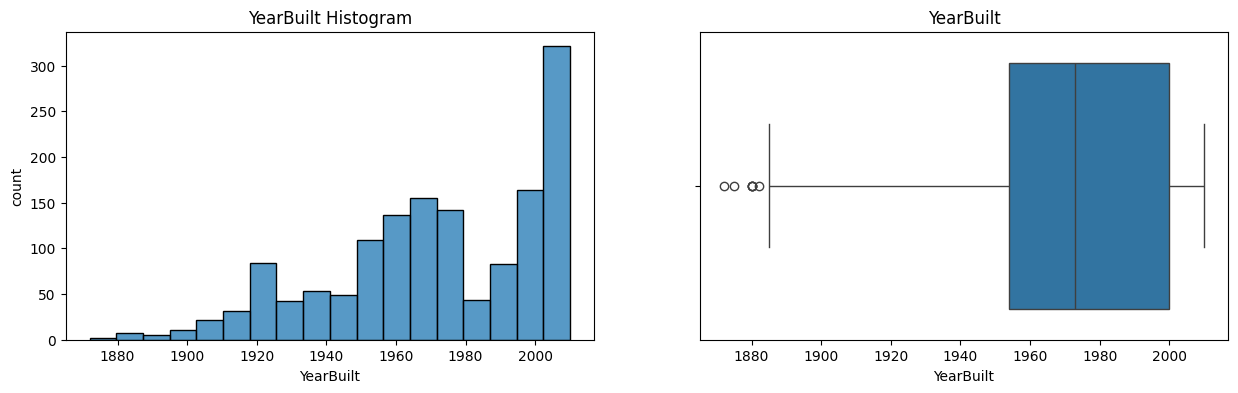

YearRemodAdd
Skew : -0.5


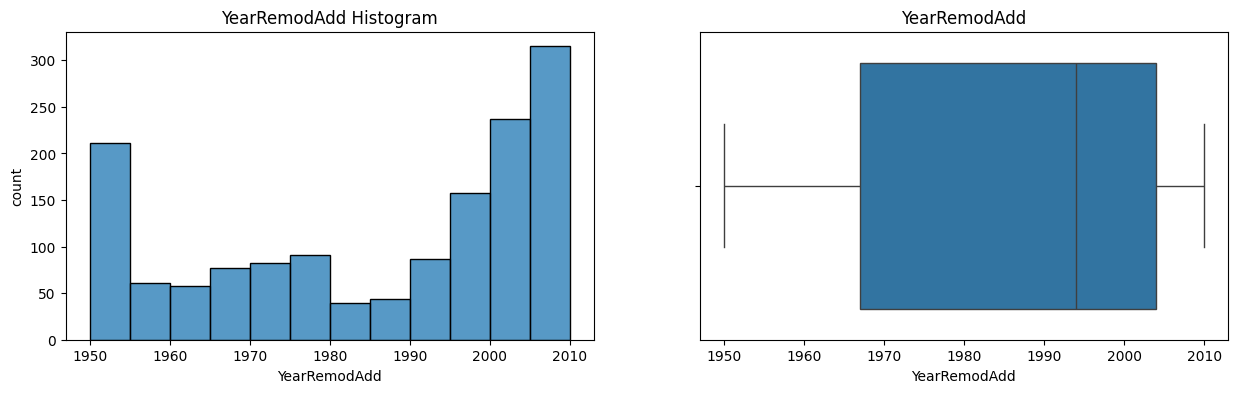

MasVnrArea
Skew : 2.67


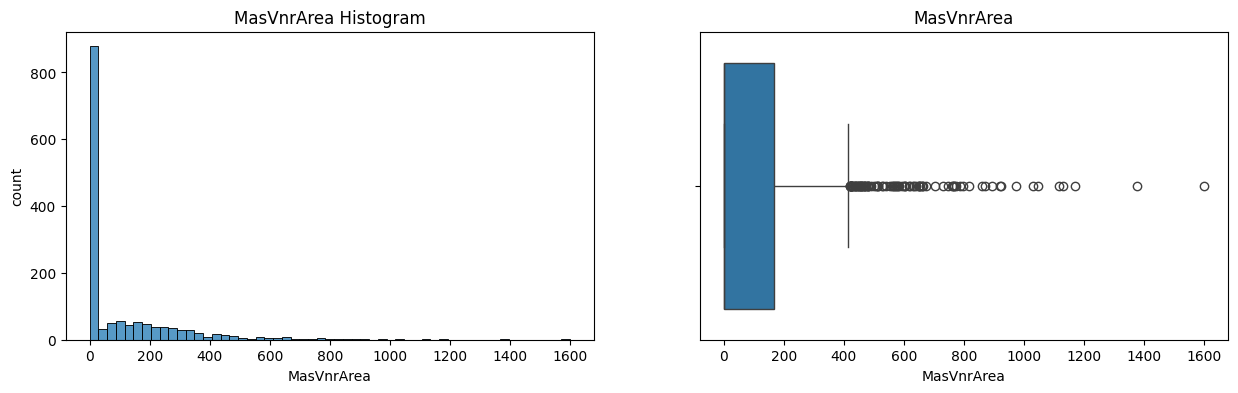

BsmtFinSF1
Skew : 1.69


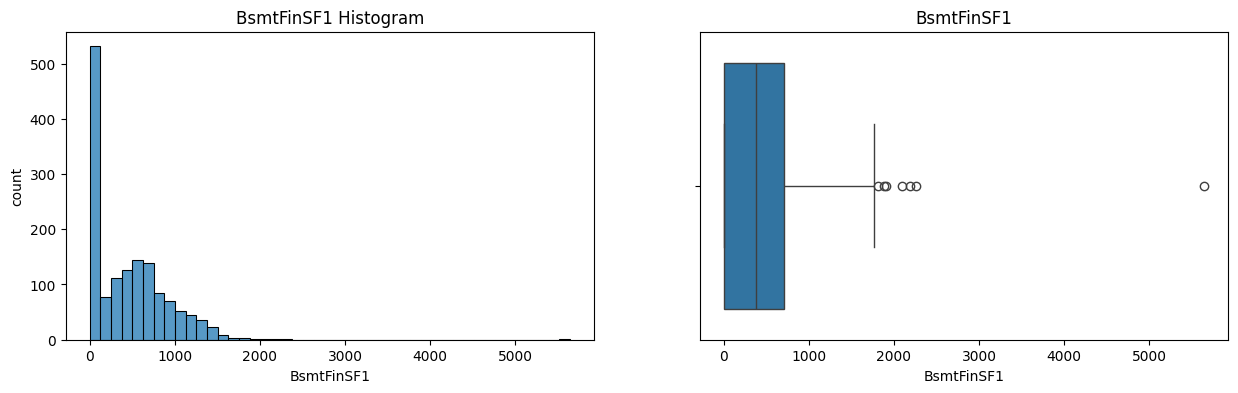

BsmtFinSF2
Skew : 4.26


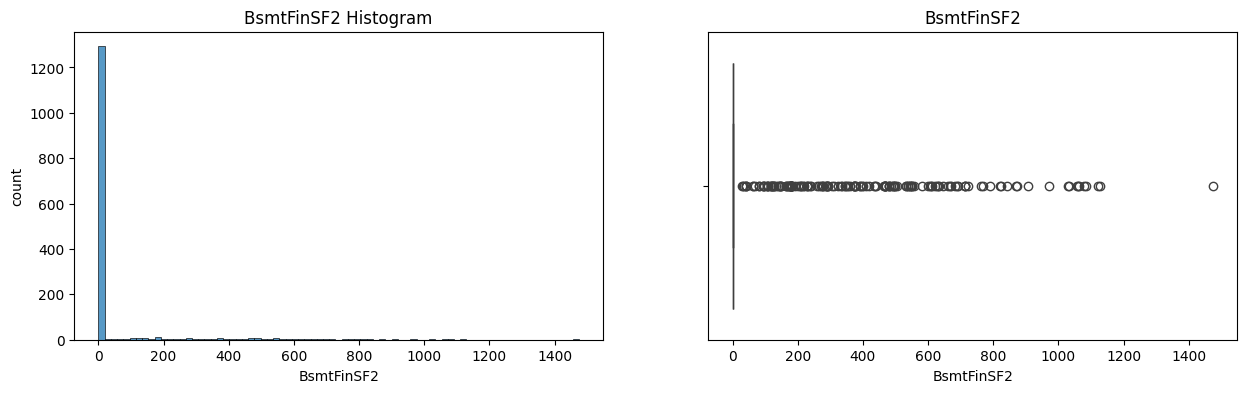

BsmtUnfSF
Skew : 0.92


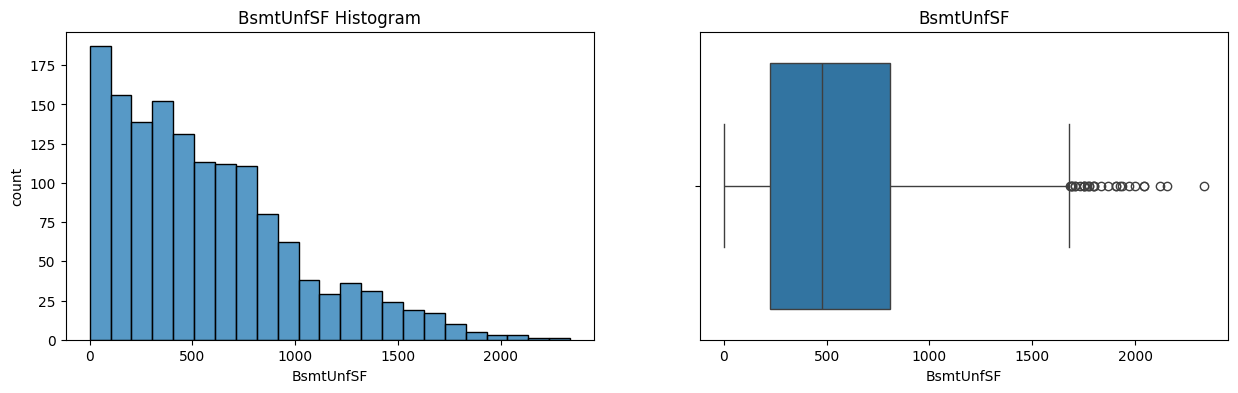

TotalBsmtSF
Skew : 1.52


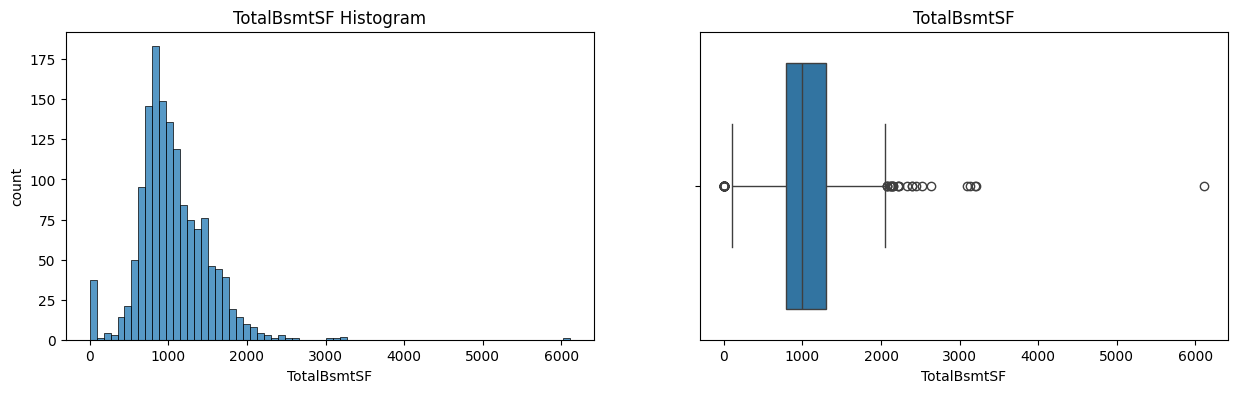

1stFlrSF
Skew : 1.38


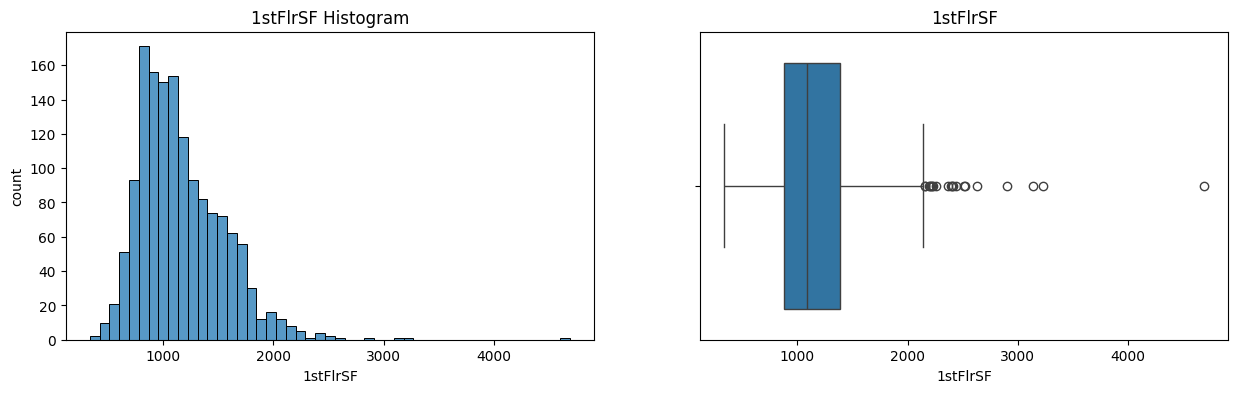

2ndFlrSF
Skew : 0.81


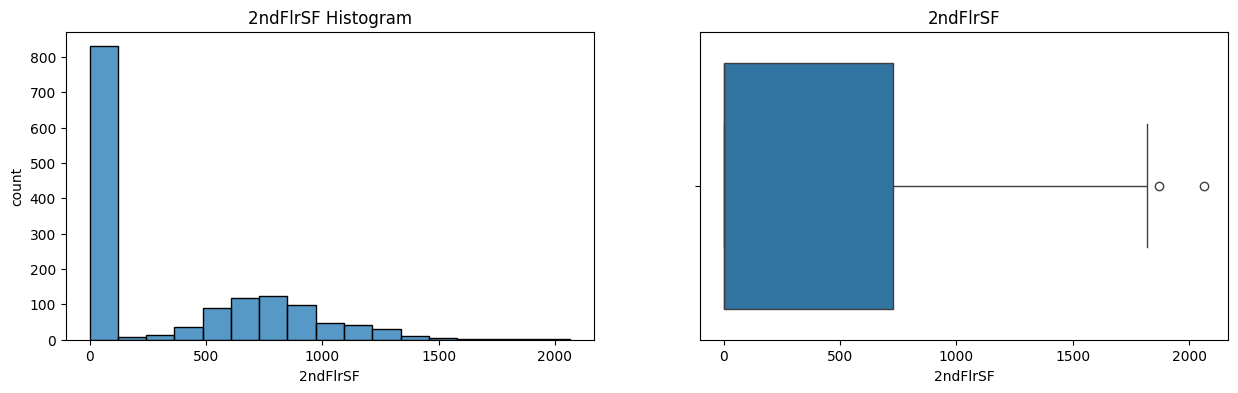

LowQualFinSF
Skew : 9.01


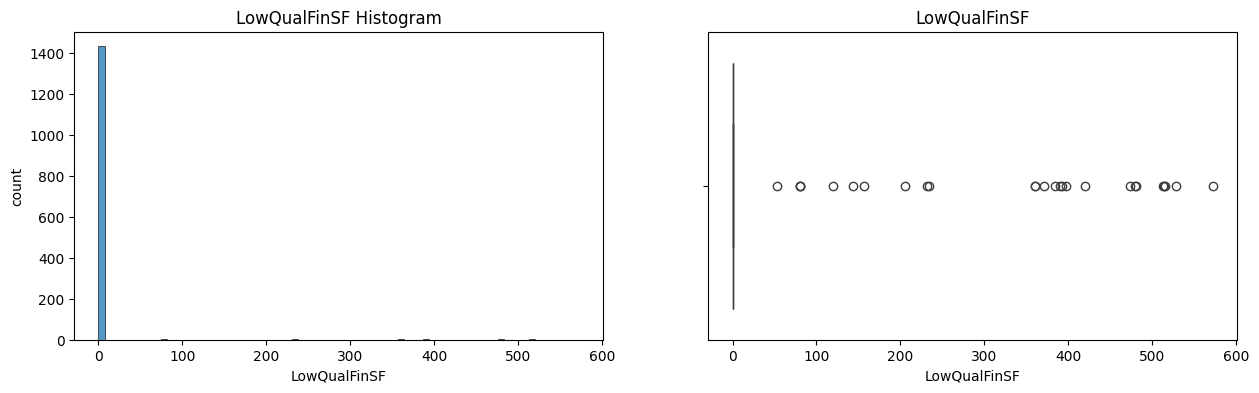

GrLivArea
Skew : 1.37


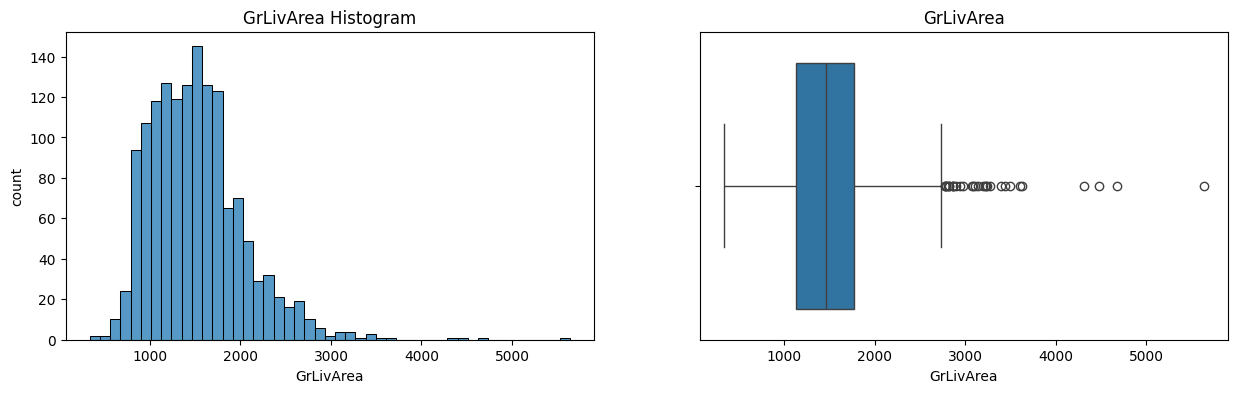

BsmtFullBath
Skew : 0.6


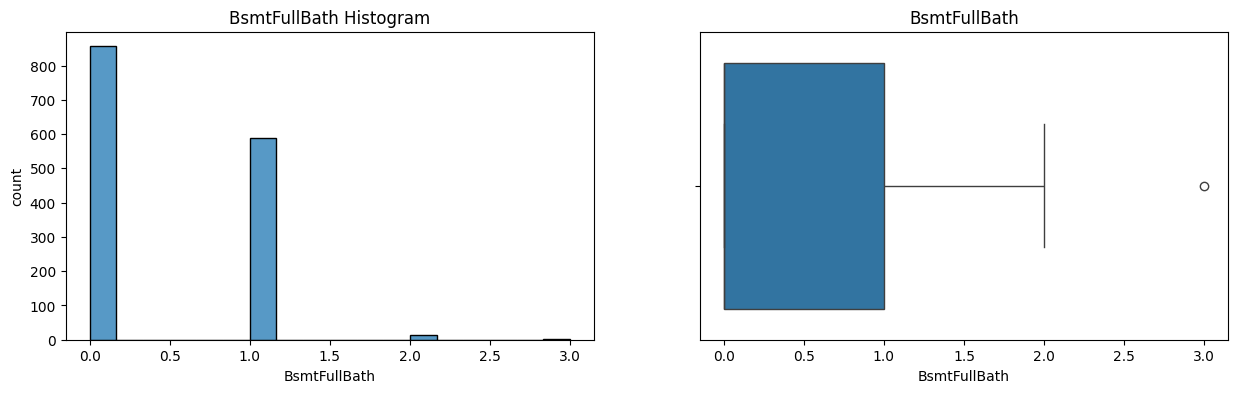

BsmtHalfBath
Skew : 4.1


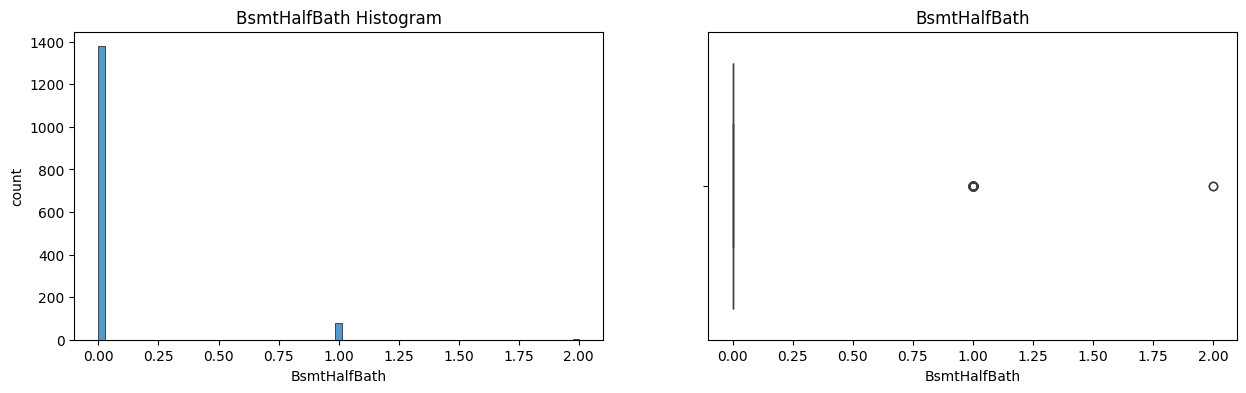

FullBath
Skew : 0.04


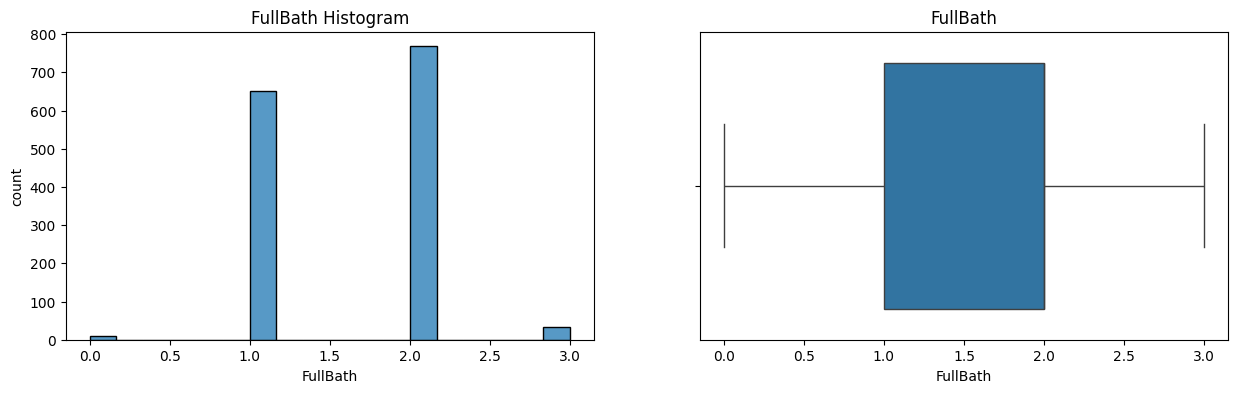

HalfBath
Skew : 0.68


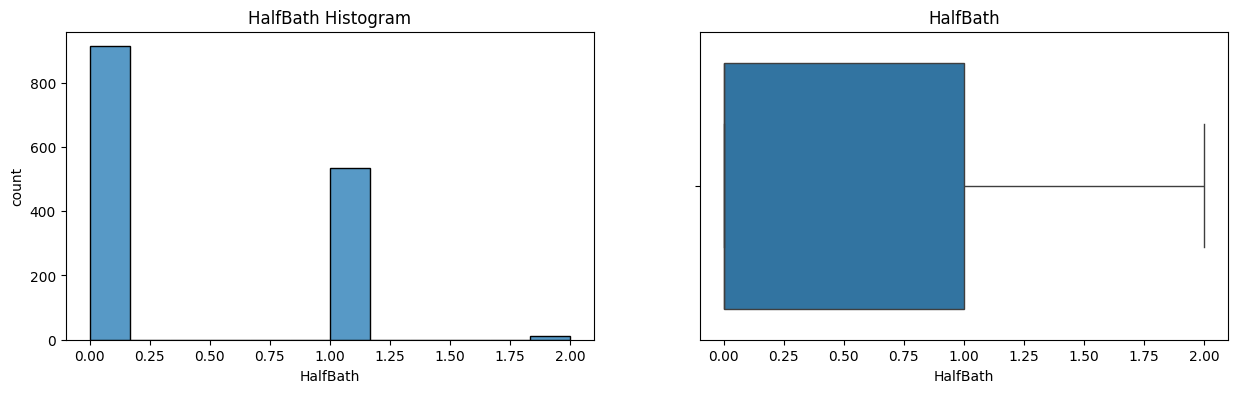

BedroomAbvGr
Skew : 0.21


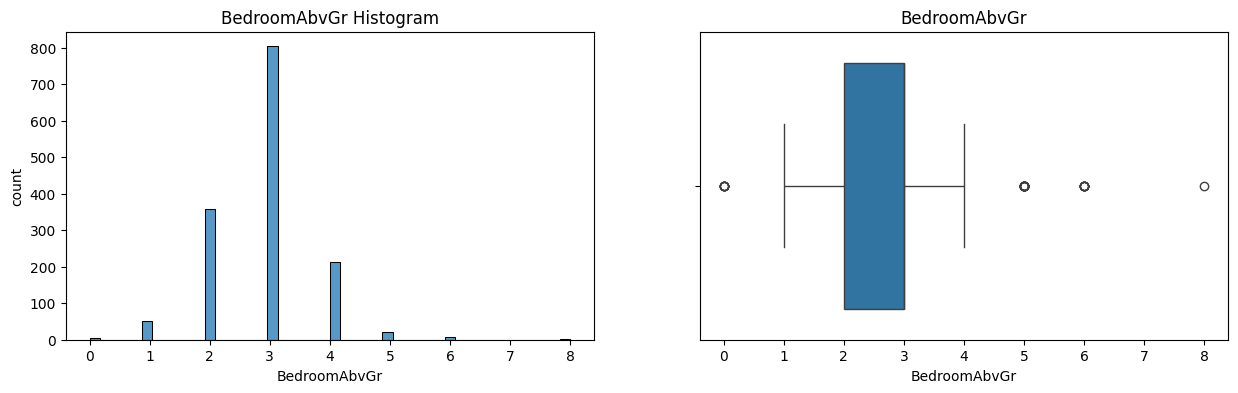

KitchenAbvGr
Skew : 4.49


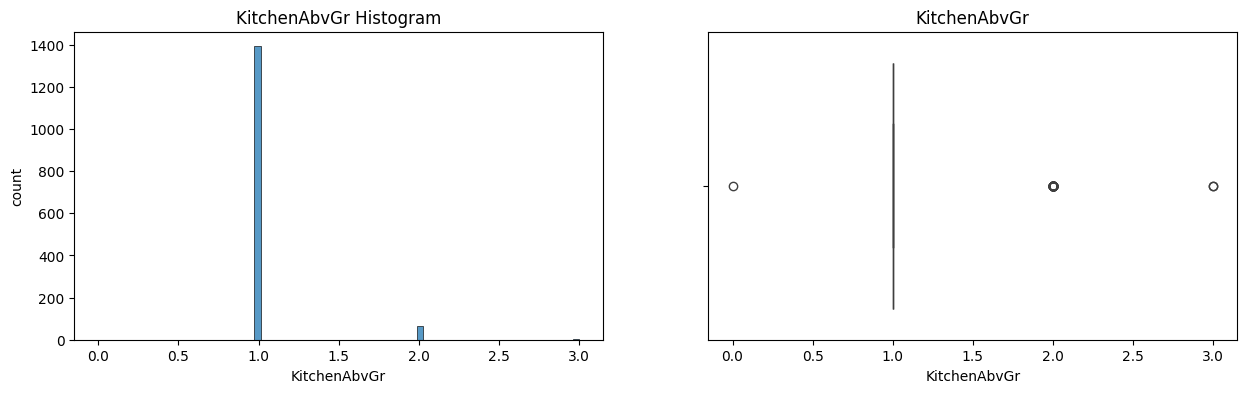

TotRmsAbvGrd
Skew : 0.68


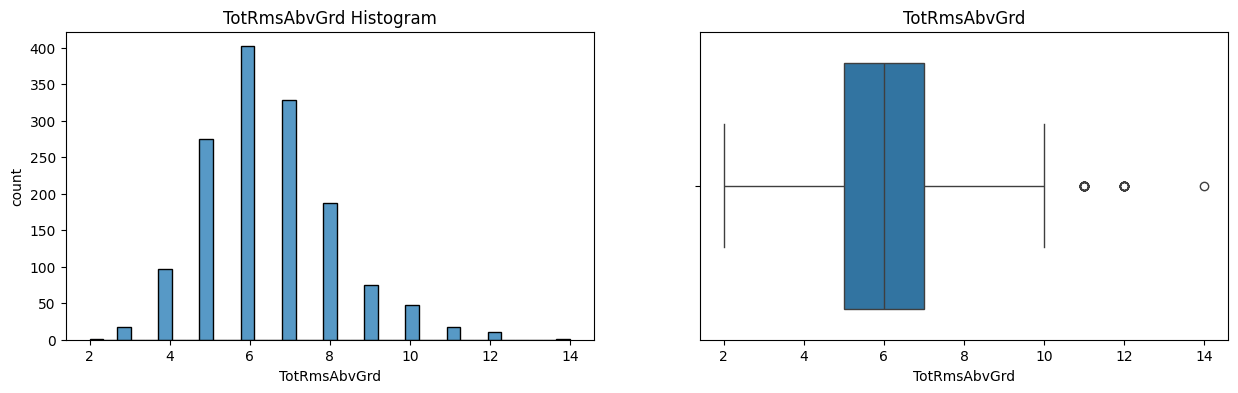

Fireplaces
Skew : 0.65


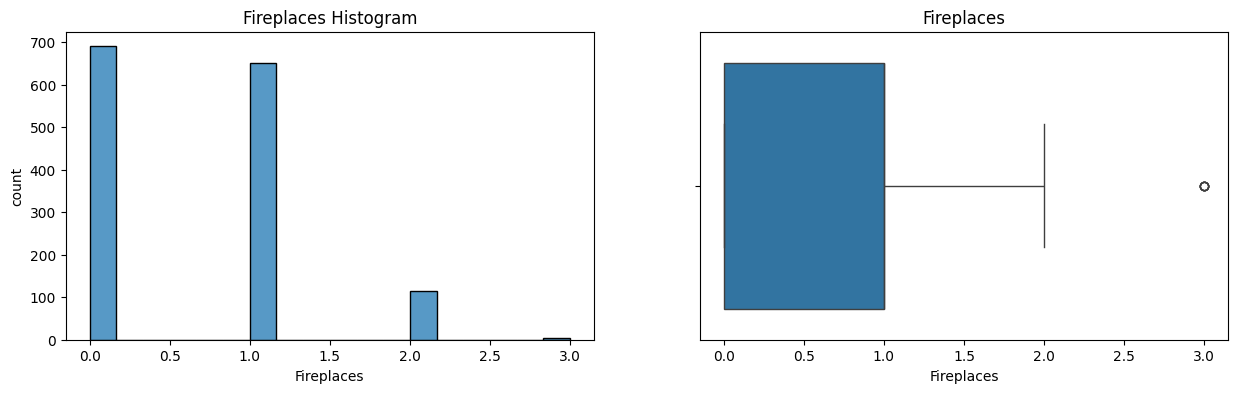

GarageYrBlt
Skew : -0.65


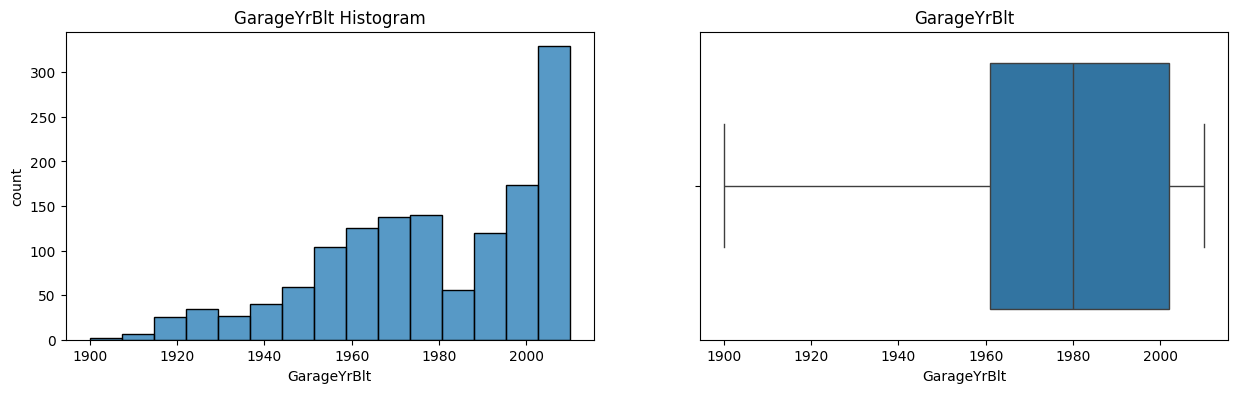

GarageCars
Skew : -0.34


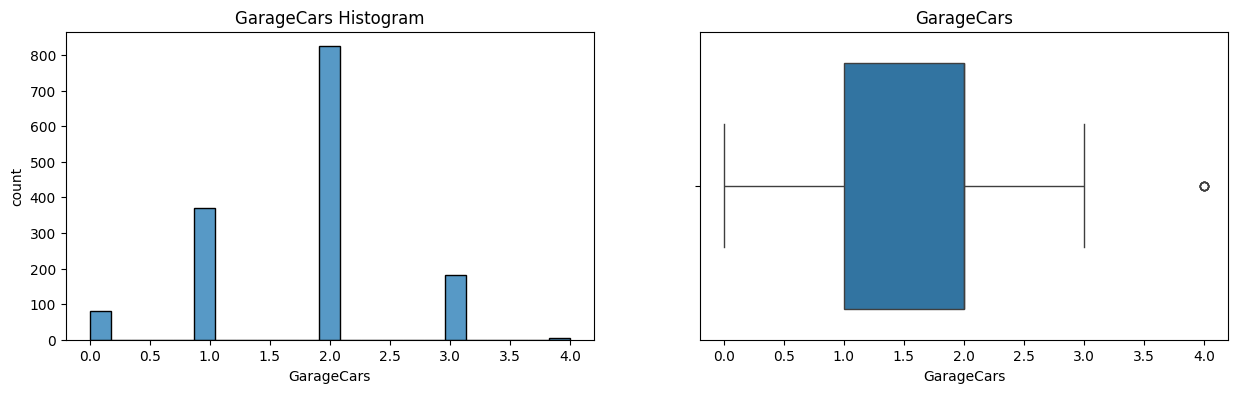

GarageArea
Skew : 0.18


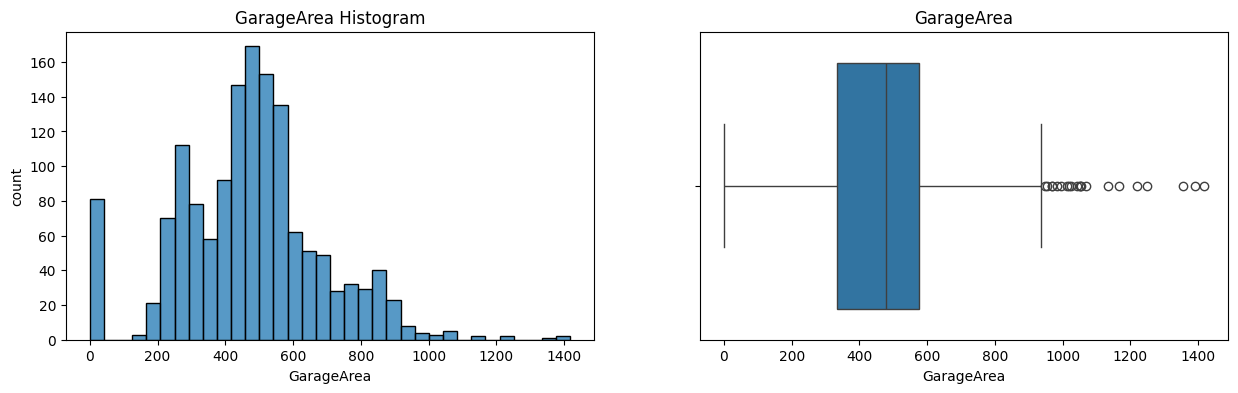

WoodDeckSF
Skew : 1.54


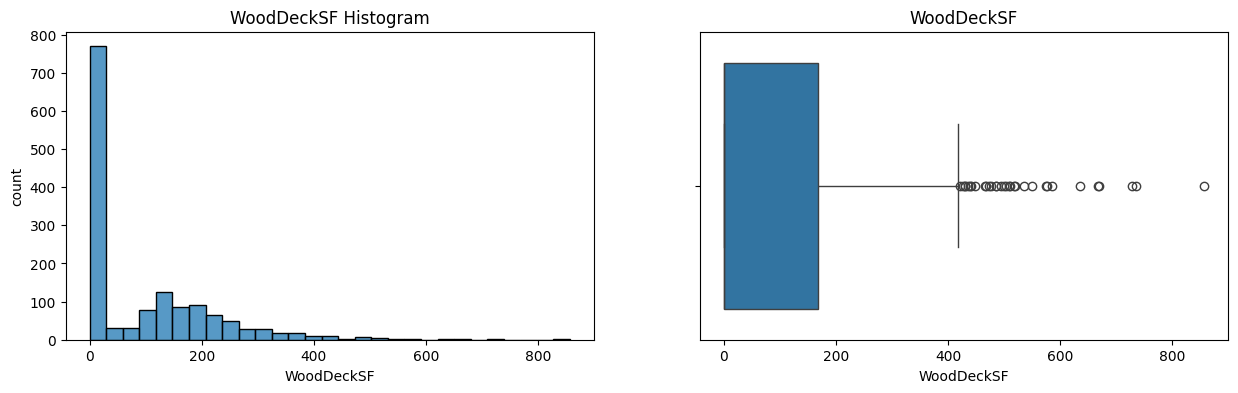

OpenPorchSF
Skew : 2.36


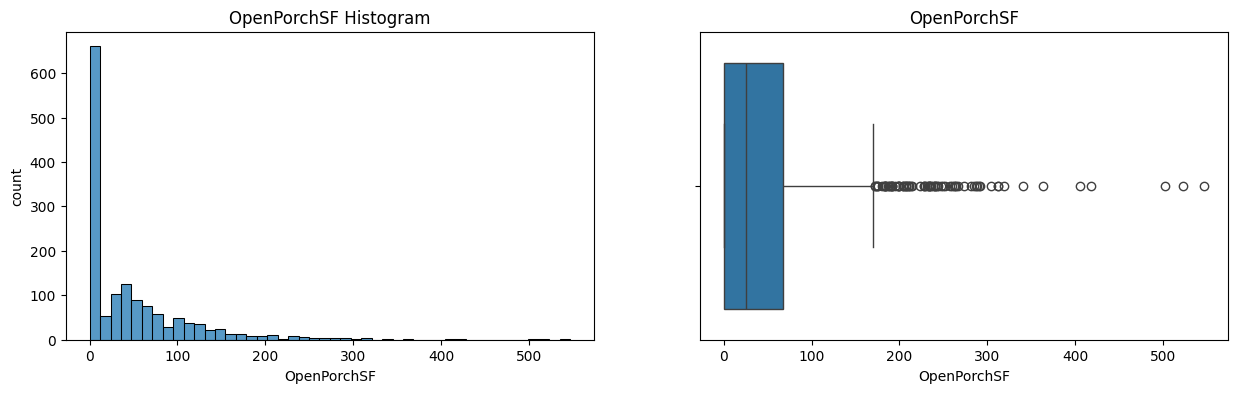

EnclosedPorch
Skew : 3.09


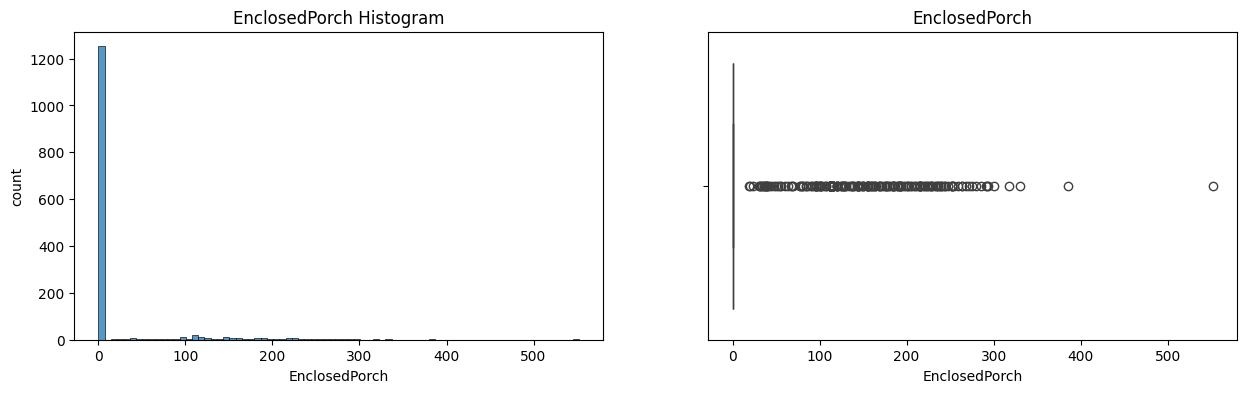

3SsnPorch
Skew : 10.3


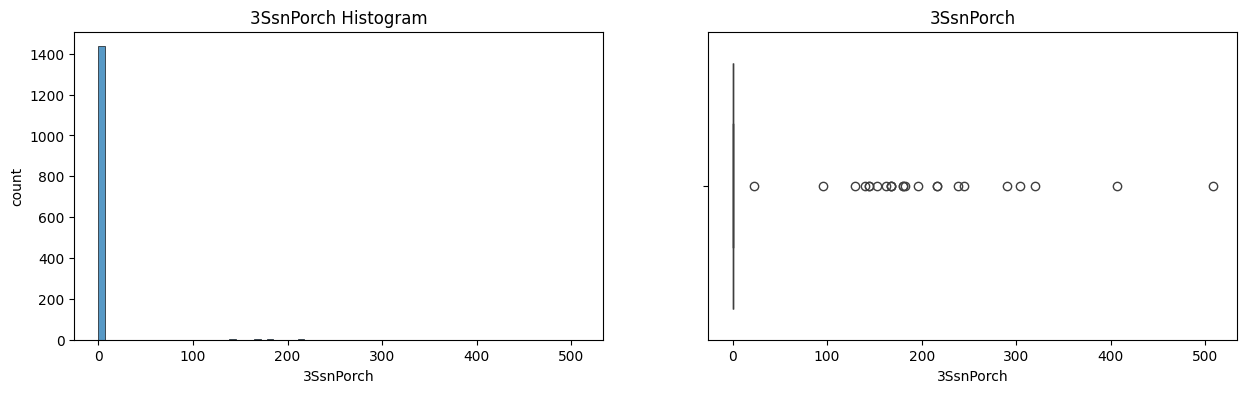

ScreenPorch
Skew : 4.12


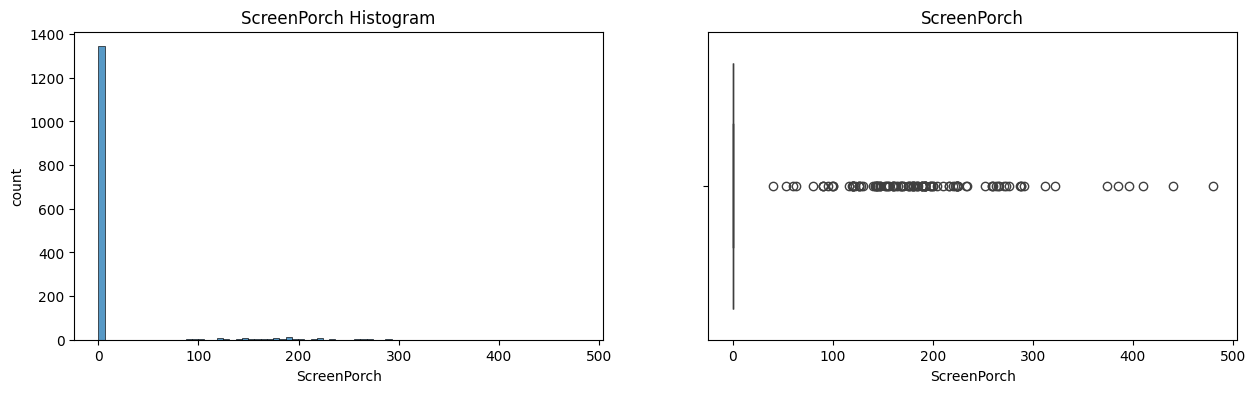

PoolArea
Skew : 14.83


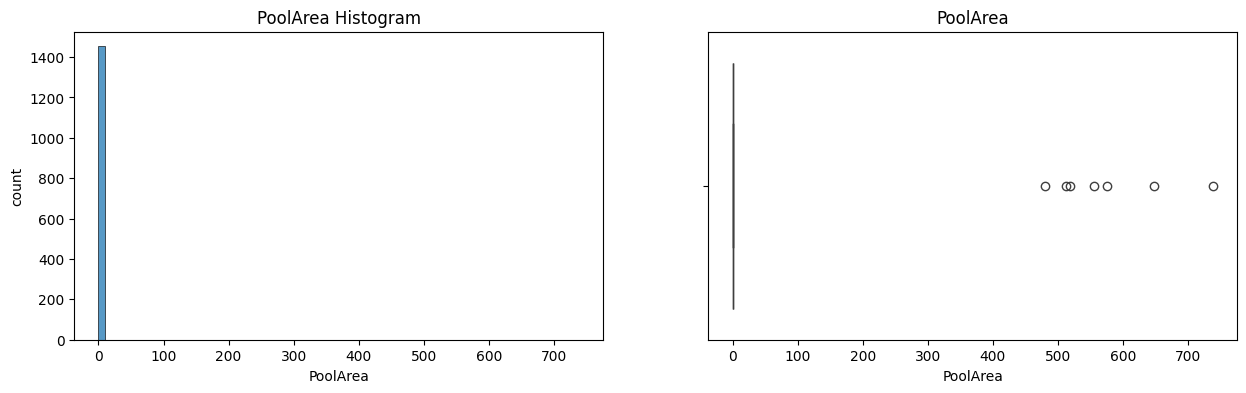

MiscVal
Skew : 24.48


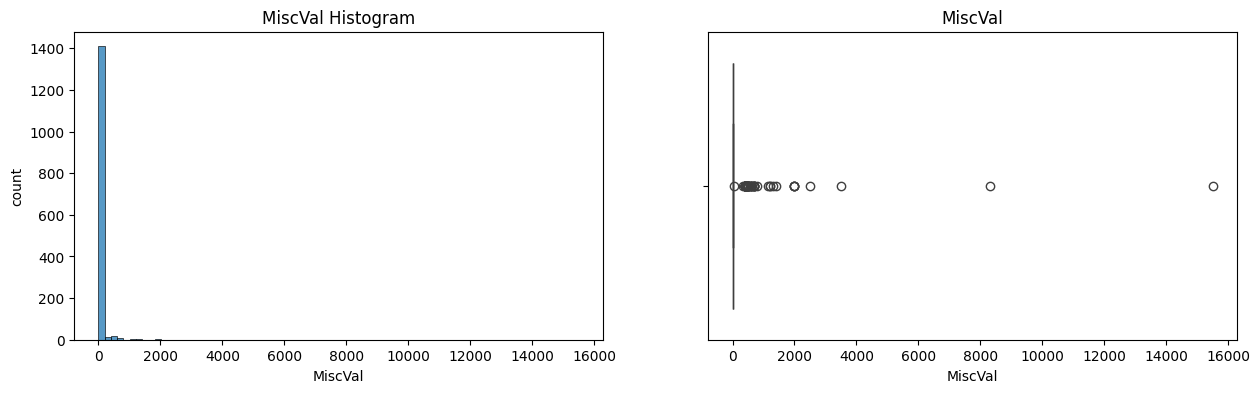

MoSold
Skew : 0.21


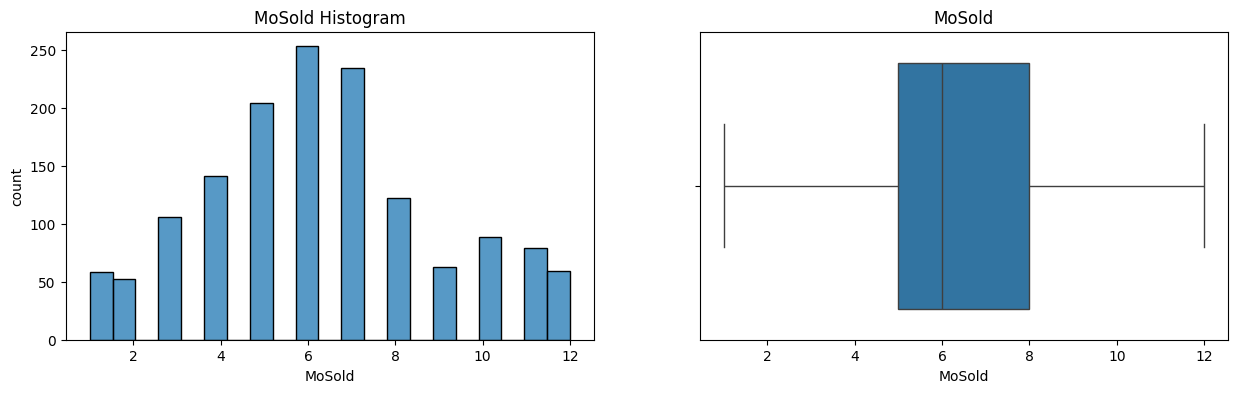

YrSold
Skew : 0.1


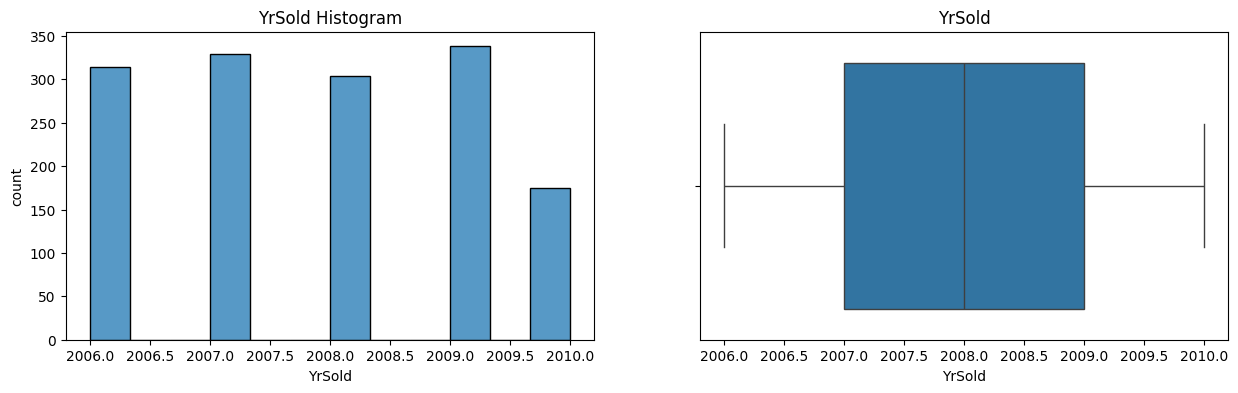

SalePrice
Skew : 1.88


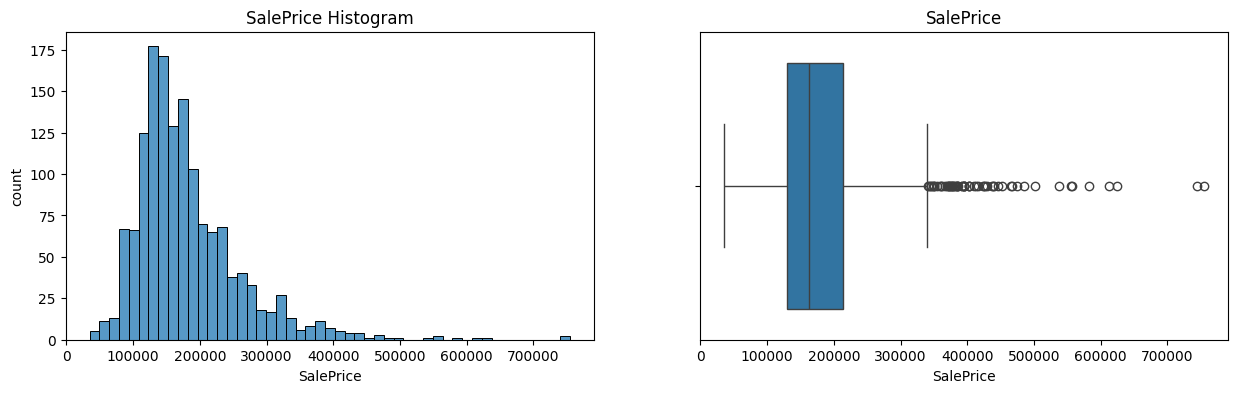

YearBuilt_AGE
Skew : 0.61


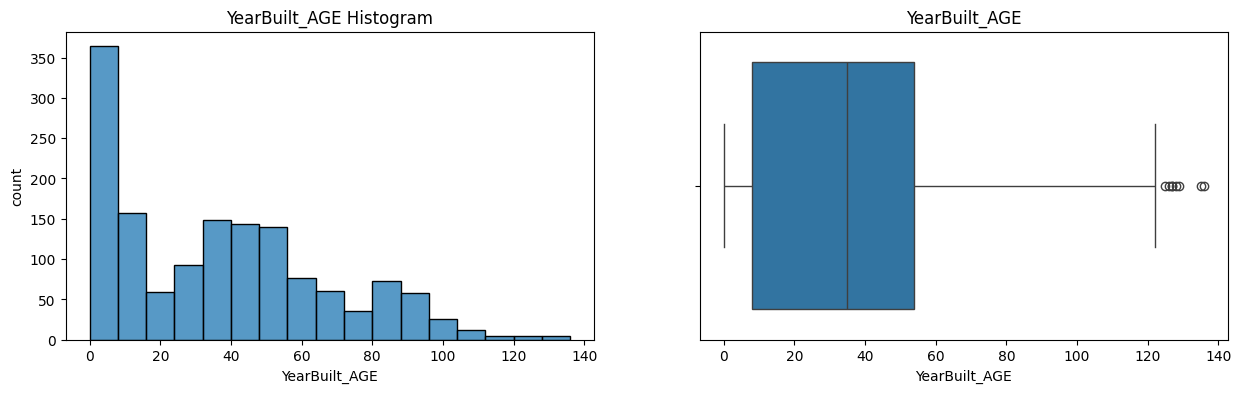

YearReMod_AGE
Skew : 0.5


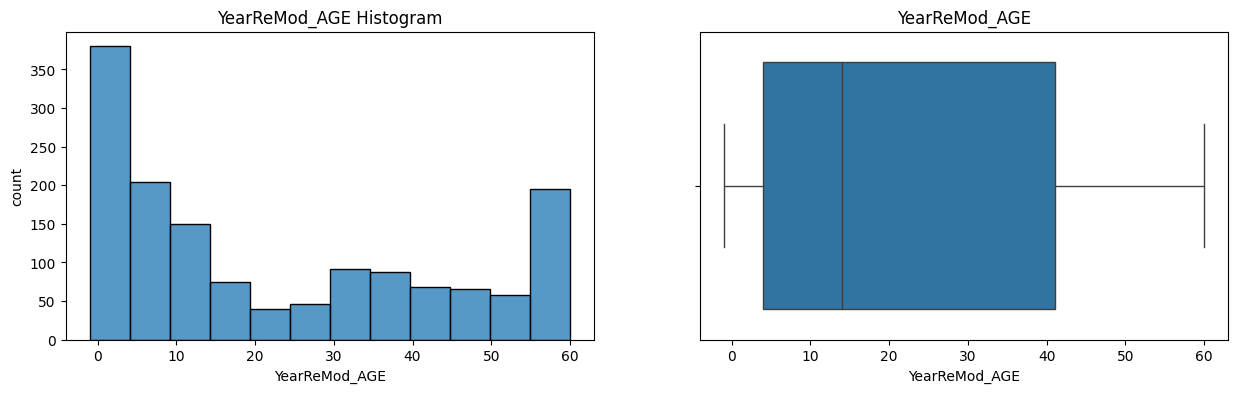

GarageYrBlt_AGE
Skew : 0.64


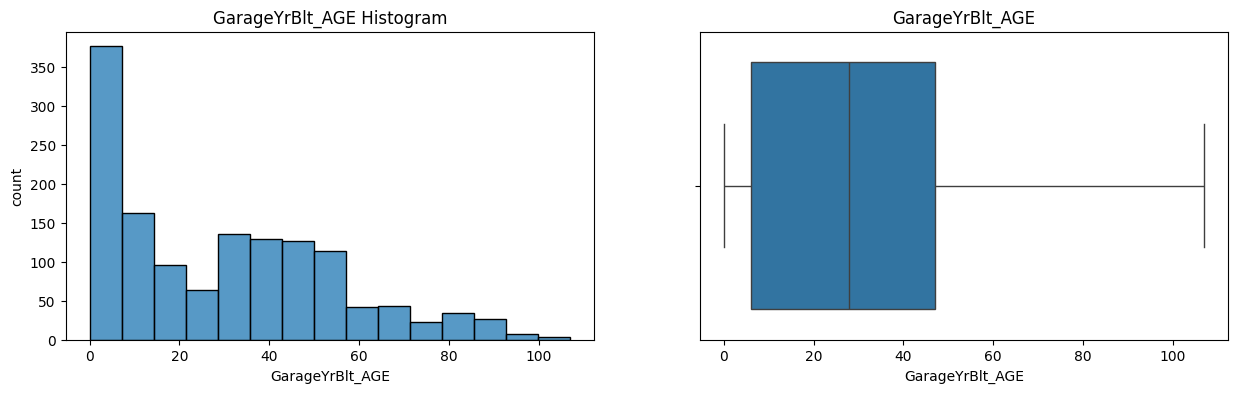

WasReModded
Skew : 0.09


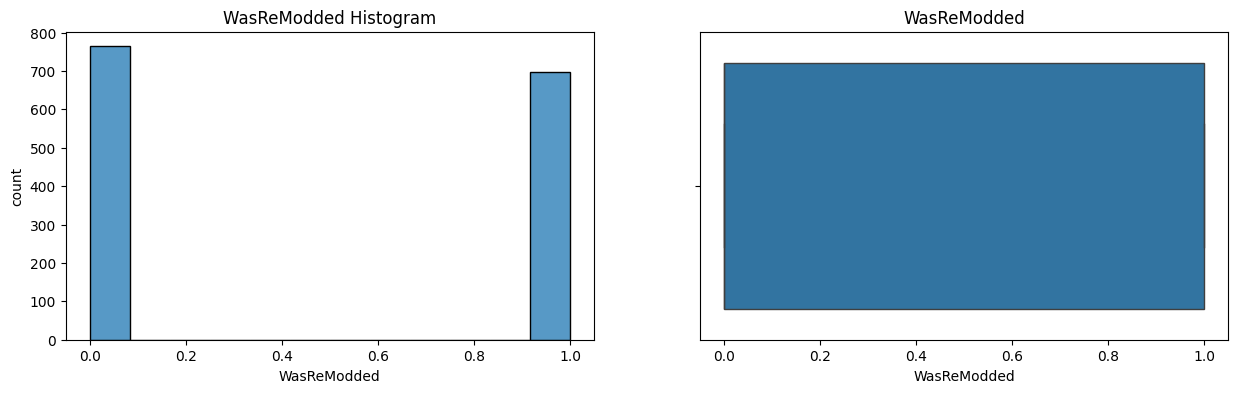

In [94]:
for col in num_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))
    plt.figure(figsize=(15, 4))
    
    # Histogram without outliers
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col)
    plt.ylabel('count')
    plt.title(f'{col} Histogram')
    
    # Boxplot without outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'{col}')
    
    plt.show()

# End